# SRILM: 3-Gram General + Domain-Specific

## Setup

In [1]:
import kenlm
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import os

In [2]:
os.environ['PATH'] = "/home/lawun330/NLP/SRILM/bin/i686-m64:" + os.environ['PATH']
!echo $PATH

/home/lawun330/NLP/SRILM/bin/i686-m64:/home/lawun330/anaconda3/envs/lu_burmese_domain_specific_lm_env/bin:/home/lawun330/.local/bin:/home/lawun330/.config/herd-lite/bin:/home/lawun330/.cargo/bin:/home/lawun330/.local/bin:/home/lawun330/.nvm/versions/node/v22.22.2/bin:/home/lawun330/anaconda3/condabin:/home/lawun330/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin


In [3]:
ROOT = Path("..").resolve()

# paths
TRAIN_DIR = ROOT / "data" / "train" / "domain-specific"
SRILM_DIR = ROOT / "models" / "srilm"
TMP_DIR = SRILM_DIR / "tmp"
PPL_DIR = SRILM_DIR / "ppl"

# general srilm model
GENERAL_LM = SRILM_DIR / "srilm_3gram.arpa"

# domain-specific training data
TRAIN_NEWS_NO_SPLIT = TRAIN_DIR / "train_news.cleaned.state3"
TRAIN_LEGAL_NO_SPLIT = TRAIN_DIR / "train_legal.cleaned.state3"
TRAIN_RELIGION_NO_SPLIT = TRAIN_DIR / "train_religion.cleaned.state3"

# splitted domain-specific training data
## news: train_news.cleaned.state3 is split into
## - train_news.train and
## - train_news.dev
NEWS_TRAIN = TRAIN_DIR / "train_news.train"
NEWS_DEV = TRAIN_DIR / "train_news.dev"

# legal: train_legal.cleaned.state3 is split into
# - train_legal.train and
# - train_legal.dev
LEGAL_TRAIN = TRAIN_DIR / "train_legal.train"
LEGAL_DEV = TRAIN_DIR / "train_legal.dev"

# religion: train_religion.cleaned.state3 is split into
# - train_religion.train and
# - train_religion.dev
RELIGION_TRAIN = TRAIN_DIR / "train_religion.train"
RELIGION_DEV = TRAIN_DIR / "train_religion.dev"

# domain-specific test data
NEWS_TEST = ROOT / "data" / "test" / "news.cleaned.state4"
LEGAL_TEST = ROOT / "data" / "test" / "legal.cleaned.state4"
RELIGION_TEST = ROOT / "data" / "test" / "religion.cleaned.state4"

ORDER = 3

CORPORA = [
    ("news", NEWS_TEST),
    ("legal", LEGAL_TEST),
    ("religion", RELIGION_TEST),
]

EVAL_SCRIPT = ROOT / "eval_kenlm_srilm.py"

sys.path.insert(0, str(ROOT))
import eval_kenlm_srilm

## Domain-Specific SRILMs

### News SRILM

In [4]:
news_arpa = f"{SRILM_DIR}/srilm_3gram_news.arpa"

In [5]:
# use -interpolate for news domain
!ngram-count \
    -order {ORDER} \
    -text {NEWS_TRAIN} \
    -lm {news_arpa} \
    -kndiscount \
    -interpolate \
    -unk \
    -map-unk "<unk>" \
    2>{news_arpa}.error

In [6]:
!head -15 {news_arpa}


\data\
ngram 1=354
ngram 2=850
ngram 3=95

\1-grams:
-2.644707	</s>
-99	<s>	-0.07040732
-2.901839	<unk>
-2.774012	Scrabble	-0.07040732
-1.40061	က	-0.1708119
-2.774012	ကန်	-0.07040732
-2.774012	ကမ္ဘာ	-0.07040732
-2.774012	ကမ္ဘာ့	-0.07040732


In [7]:
!cat {news_arpa}.error

### Legal SRILM 

In [8]:
legal_arpa = f"{SRILM_DIR}/srilm_3gram_legal.arpa"

In [9]:
# use -interpolate for legal domain
!ngram-count \
    -order {ORDER} \
    -text {LEGAL_TRAIN} \
    -lm {legal_arpa} \
    -kndiscount \
    -interpolate \
    -unk \
    -map-unk "<unk>" \
    2>{legal_arpa}.error

In [10]:
!head -15 {legal_arpa}


\data\
ngram 1=365
ngram 2=1121
ngram 3=424

\1-grams:
-1.874453	</s>
-99	<s>	-0.2414797
-3.009174	<unk>
-2.647841	Identification	-0.09450395
-2.885054	NumberUID	-0.09450394
-2.885054	of	-0.09450395
-2.009493	က	-0.19936
-2.885054	ကတ်	-0.09450395


In [11]:
!cat {legal_arpa}.error

### Religion SRILM

In [12]:
religion_arpa = f"{SRILM_DIR}/srilm_3gram_religion.arpa"

In [13]:
# do not use -interpolate for religion domain
!ngram-count \
    -order {ORDER} \
    -text {RELIGION_TRAIN} \
    -lm {religion_arpa} \
    -kndiscount \
    -unk \
    -map-unk "<unk>" \
    2>{religion_arpa}.error

In [14]:
!head -15 {religion_arpa}


\data\
ngram 1=377
ngram 2=1056
ngram 3=154

\1-grams:
-1.267757	</s>
-99	<s>	-0.1107469
-0.5232657	<unk>
-2.421147	က	-0.04765644
-3.417811	ကင်း	-0.07456744
-3.211848	ကန်	-0.0710127
-3.211848	ကမ္မဋ္ဌာန်း	-0.06768154
-3.211848	ကာ	-0.06600455


In [15]:
!cat {religion_arpa}.error

### ARPA to Binary

In [16]:
!build_binary {news_arpa} {news_arpa}.binary
!build_binary {legal_arpa} {legal_arpa}.binary
!build_binary {religion_arpa} {religion_arpa}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_news.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS
Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_legal.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS
Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_religion.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## Mixed SRILMs

### General + News SRILM

In [17]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_news.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_news.ppl"

In [18]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {NEWS_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {news_arpa} -ppl {NEWS_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 190725 3-grams
reading 354 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_news.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 850 2-grams
reading 95 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 56.7853
iteration 2, lambda = (0.580651 0.419349), ppl = 55.6668
iteration 3, lambda = (0.622481 0.377519), ppl = 55.3581
iteration 4, lambda = (0.644522 0.355478), ppl = 55.2694
iteration 5, lambda = (0.656343 0.343657), ppl = 55.2432
iteration 6, lambda = (0.662762 0.337238), ppl = 55.2354
iteration 7, lambda = (0.666274 0.333726), ppl = 55.233
iteration 8, lambda = (0.668203 0.331797), ppl = 55.2323
iteration 9, lambda = (0.669266 0.330734), ppl = 55.2321
6703 non-oov words, best lambda (0.669852 0.330148)
pairwis

In [19]:
# mix general and news LMs
COMBINED_LM = f"{SRILM_DIR}/srilm_3gram_general_plus_news.arpa"
lambda_for_gen_lm = 0.669852  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {news_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_news.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM


In [20]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_general_plus_news.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


### General + Legal SRILM

In [21]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_legal.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_legal.ppl"

In [22]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {LEGAL_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {legal_arpa} -ppl {LEGAL_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 190725 3-grams
reading 365 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_legal.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 1121 2-grams
reading 424 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 10.8636
iteration 2, lambda = (0.350479 0.649521), ppl = 10.124
iteration 3, lambda = (0.270799 0.729201), ppl = 9.89766
iteration 4, lambda = (0.228427 0.771573), ppl = 9.82495
iteration 5, lambda = (0.205254 0.794746), ppl = 9.80082
iteration 6, lambda = (0.192234 0.807766), ppl = 9.79264
iteration 7, lambda = (0.184773 0.815227), ppl = 9.78983
iteration 8, lambda = (0.180442 0.819558), ppl = 9.78886
iteration 9, lambda = (0.177908 0.822092), ppl = 9.78852
iteration 10, lambda = (0.176417 0.823583), ppl = 9.7884

In [23]:
# mix general and legal LMs
COMBINED_LM = f"{SRILM_DIR}/srilm_3gram_general_plus_legal.arpa"
lambda_for_gen_lm = 0.175538  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {legal_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_legal.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM


In [24]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_general_plus_legal.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## General + Religion SRILM

In [25]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_religion.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_religion.ppl"

In [26]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {RELIGION_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {religion_arpa} -ppl {RELIGION_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 190725 3-grams
reading 377 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_religion.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 1056 2-grams
reading 154 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 46.8871
iteration 2, lambda = (0.336486 0.663514), ppl = 43.3448
iteration 3, lambda = (0.266557 0.733443), ppl = 42.6257
iteration 4, lambda = (0.234836 0.765164), ppl = 42.4579
iteration 5, lambda = (0.219538 0.780462), ppl = 42.4156
iteration 6, lambda = (0.211876 0.788124), ppl = 42.4045
iteration 7, lambda = (0.207956 0.792044), ppl = 42.4015
iteration 8, lambda = (0.205928 0.794072), ppl = 42.4007
iteration 9, lambda = (0.204872 0.795128), ppl = 42.4005
1494 non-oov words, best lambda (0.20432 0.79568)
pa

In [27]:
# mix general and religion LMs
COMBINED_LM = f"{SRILM_DIR}/srilm_3gram_general_plus_religion.arpa"
lambda_for_gen_lm = 0.20432  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {religion_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa: line 87: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_religion.arpa: line 10: warning: non-zero probability for <unk> in closed-vocabulary LM


In [28]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_general_plus_religion.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## Model Loading

In [29]:
# load only binary models

try:
    # general LM
    general_lm = kenlm.LanguageModel(f"{GENERAL_LM}.ken.binary")

    # domain LMs
    domain_lm_news = kenlm.LanguageModel(f"{news_arpa}.binary")
    domain_lm_legal = kenlm.LanguageModel(f"{legal_arpa}.binary")
    domain_lm_religion = kenlm.LanguageModel(f"{religion_arpa}.binary")

    # general + domain LMs
    combined_lm_news = kenlm.LanguageModel(f"{SRILM_DIR}/srilm_3gram_general_plus_news.arpa.binary")
    combined_lm_legal = kenlm.LanguageModel(f"{SRILM_DIR}/srilm_3gram_general_plus_legal.arpa.binary")
    combined_lm_religion = kenlm.LanguageModel(f"{SRILM_DIR}/srilm_3gram_general_plus_religion.arpa.binary")

    print("Models loaded successfully.")

except Exception as e:
    print(f"Error loading models: {e}")

Models loaded successfully.


In [30]:
MODELS = [
    ("general", general_lm),
    ("news", domain_lm_news),
    ("legal", domain_lm_legal),
    ("religion", domain_lm_religion),
    ("general_plus_news", combined_lm_news),
    ("general_plus_legal", combined_lm_legal),
    ("general_plus_religion", combined_lm_religion),
]

## Model Evaluation

In [31]:
def should_evaluate(tag, corpus_name):
    if tag == "general":
        return True
    if tag in ("news", "legal", "religion"):
        return tag == corpus_name
    if tag == "general_plus_news":
        return corpus_name == "news"
    if tag == "general_plus_legal":
        return corpus_name == "legal"
    if tag == "general_plus_religion":
        return corpus_name == "religion"
    return False

In [32]:
rows = []
for corpus_name, corpus_path in CORPORA:
    row = {"corpus": corpus_name}
    for tag, model in MODELS:
        if should_evaluate(tag, corpus_name):
            ppl, ent, bpc = eval_kenlm_srilm.evaluate(model, corpus_path)
            row[f"ppl_{tag}"] = ppl
            row[f"ent_{tag}"] = ent
            row[f"bpc_{tag}"] = bpc
        else:
            row[f"ppl_{tag}"] = np.nan
            row[f"ent_{tag}"] = np.nan
            row[f"bpc_{tag}"] = np.nan
    rows.append(row)

In [33]:
df_eval = pd.DataFrame(rows).set_index("corpus")
df_eval

,ppl_general,ent_general,bpc_general,ppl_news,ent_news,bpc_news,ppl_legal,ent_legal,bpc_legal,ppl_religion,...,bpc_religion,ppl_general_plus_news,ent_general_plus_news,bpc_general_plus_news,ppl_general_plus_legal,ent_general_plus_legal,bpc_general_plus_legal,ppl_general_plus_religion,ent_general_plus_religion,bpc_general_plus_religion
corpus,,,,,,,,,,,,,,,,,,,,,
news,123.024798,4.812386,1.794080,234.656458,5.458123,2.034814,NaN,NaN,NaN,NaN,...,NaN,115.89762,4.752707,1.771832,NaN,NaN,NaN,NaN,NaN,NaN
legal,179.244206,5.188749,1.939162,NaN,NaN,NaN,156.608659,5.05375,1.88871,NaN,...,NaN,NaN,NaN,NaN,117.921627,4.77002,1.782673,NaN,NaN,NaN
religion,275.025653,5.616864,2.106088,NaN,NaN,NaN,NaN,NaN,NaN,33.038632,...,1.311482,NaN,NaN,NaN,NaN,NaN,NaN,54.854296,4.00468,1.501586


## Visualization

In [34]:
mix_suffix = {
    "news": "general_plus_news",
    "legal": "general_plus_legal",
    "religion": "general_plus_religion",
}

metrics = [
    ("ppl", "Perplexity (PPL)", True),   # log scale
    ("ent", "Entropy (nats)", False),
    ("bpc", "Bits per character (BPC)", False),
]

x = np.arange(len(df_eval.index))
w = 0.25
offsets = np.array([-w, 0.0, w])
labels_bar = ["General", "Domain only", "Mixed"]
colors = ["#AEB8C6", "#1E4FA8", "#191970"]

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/srilm_general_domain_mix_metrics.png


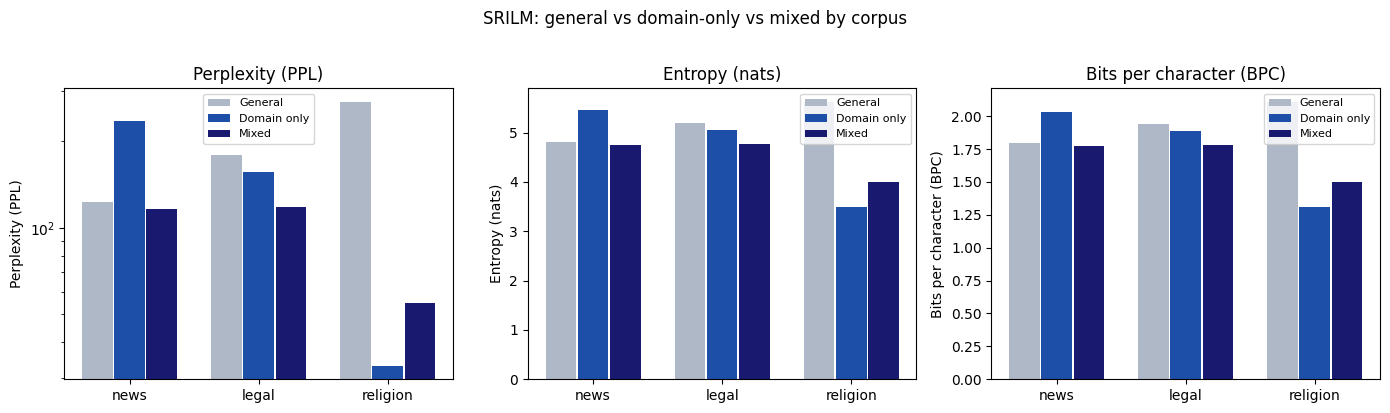

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    gen_vals = []
    dom_vals = []
    mix_vals = []
    for corpus in df_eval.index:
        gen_vals.append(df_eval.loc[corpus, f"{prefix}_general"])
        dom_vals.append(df_eval.loc[corpus, f"{prefix}_{corpus}"])
        mix_vals.append(df_eval.loc[corpus, f"{prefix}_{mix_suffix[corpus]}"])
    for off, vals, lab, c in zip(
        offsets,
        [gen_vals, dom_vals, mix_vals],
        labels_bar,
        colors,
    ):
        ax.bar(x + off, vals, width=w * 0.95, label=lab, color=c)
    ax.set_xticks(x, list(df_eval.index))
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(loc="best", fontsize=8)
    if use_log:
        ax.set_yscale("log")

fig.suptitle("SRILM: general vs domain-only vs mixed by corpus", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "srilm_general_domain_mix_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

## Conclusion

### Model-Wise

The mixed model performs better in its corresponding domain, as reflected by:

- lower perplexity
- lower entropy
- lower bits-per-character

Although the mixed model performs slightly worse than the domain-only model on the religion domain, its performance remains comparable, and the difference may reflect domain-specific training data (e.g. size or coverage).